<a href="https://colab.research.google.com/github/LL-green-hub/CodeForPFAS_VOC_NHANES20052020/blob/main/0916forGitHub_TMLE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scikit-learn pandas numpy statsmodels


In [ ]:
import os
import numpy as np
import pandas as pd

def build_maximum_dataset(folder_path="."):
    """Scans and merges multi-cycle NHANES files with adaptive column mapping."""
    configs = [
        ('05-06', 'D', '06', 'WTSB2YR'),
        ('07-08', 'E', '08', 'WTSB2YR'),
        ('09-10', 'F', '10', 'WTSB2YR'),
        ('11-12', 'G', '12', 'WTSB2YR'),
        ('13-14', 'H', '14', 'WTSB2YR'),
        ('15-16', 'I', '16', 'WTSB2YR'),
        ('17-20', '20', '20', 'WTPFAPRP')
    ]

    all_data = []
    for cycle, suffix, yr, weight in configs:
        print(f"📦 Scanning cycle: {cycle} ...")

        # 1. Locate and read core PFAS file
        pfas_f = next((f for f in os.listdir(folder_path) if suffix in f and ('PFC' in f or 'PFAS' in f) and f.endswith('.xpt')), None)
        if not pfas_f:
            print(f"  ⚠️ Warning: PFAS file not found for cycle {cycle}. Skipping.")
            continue
        df = pd.read_sas(os.path.join(folder_path, pfas_f), format='xport')
        df.columns = df.columns.str.upper()

        # 2. Robust conditional join pipeline
        def safe_merge(base_df, pattern):
            target_f = next((f for f in os.listdir(folder_path) if pattern in f.upper() and (yr in f or (suffix == '20' and 'P_' in f.upper())) and f.endswith('.xpt')), None)
            if target_f:
                try:
                    new_df = pd.read_sas(os.path.join(folder_path, target_f), format='xport')
                    new_df.columns = new_df.columns.str.upper()
                    base_df['SEQN'] = base_df['SEQN'].astype(int)
                    new_df['SEQN'] = new_df['SEQN'].astype(int)
                    return pd.merge(base_df, new_df, on='SEQN', how='left')
                except Exception as e:
                    print(f"  ⚠️ Failed to merge {pattern}: {e}")
            return base_df

        df = safe_merge(df, 'DEMO')    # Demographics
        df = safe_merge(df, 'UVOC')    # Volatile Organic Compounds Metabolites
        df = safe_merge(df, 'ALB_CR')  # Urinary Creatinine
        df = safe_merge(df, 'BMX')     # Body Mass Index File

        # Adaptive scanning for biochemistry file (BIOPRO for standard cycles, BIOPR/P_BIOPR for 2017-2020)
        df = safe_merge(df, 'BIOPRO')
        df = safe_merge(df, 'BIOPR')

        df['Cycle'] = cycle
        all_data.append(df)

    if not all_data:
        print("❌ Critical Error: No data sheets loaded. Please check folder_path.")
        return pd.DataFrame()

    master = pd.concat(all_data, ignore_index=True)

    # 3. Label harmonization and dual-creatinine segregation
    pfas_map = {'LBXPFOA': 'PFOA', 'LBXPFOS': 'PFOS', 'LBXPFNA': 'PFNA', 'LBXPFHS': 'PFHxS'}
    master.rename(columns=pfas_map, inplace=True)

    master['AGE'] = master.get('RIDAGEYR', master.get('RIDAGE'))
    master['GENDER'] = master.get('RIAGENDR')

    # Extract Urine Creatinine for VOC outcome standardization
    master['URINE_CREATININE'] = master.get('URXUCR')

    # Adaptive mapping for Serum Creatinine across different NHANES releases (LBXSCR or LBXSC1)
    master['SERUM_CREATININE'] = master.get('LBXSCR', master.get('LBXSC1'))

    print(f"🔥 Master dataset constructed! Initial Sample Size N = {len(master)}")
    return master

def calculate_egfr_ckd_epi_2021(df):
    """Calculates race-free eGFR using the 2021 CKD-EPI equation."""
    if df.empty: return df
    res_df = df.copy()
    is_female = (res_df['GENDER'] == 2)

    kappa = np.where(is_female, 0.7, 0.9)
    alpha = np.where(is_female, -0.241, -0.302)
    gender_constant = np.where(is_female, 1.012, 1.0)

    scr_div_kappa = res_df['SERUM_CREATININE'] / kappa
    scr_div_kappa = np.clip(scr_div_kappa, 1e-5, None)

    term_min = np.minimum(scr_div_kappa, 1.0) ** alpha
    term_max = np.maximum(scr_div_kappa, 1.0) ** (-1.200)
    term_age = 0.9938 ** res_df['AGE']

    res_df['eGFR'] = 142 * term_min * term_max * term_age * gender_constant
    return res_df

# Execute data preparation pipeline
df_raw = build_maximum_dataset()
df_raw = calculate_egfr_ckd_epi_2021(df_raw)

if not df_raw.empty:
    print("✅ eGFR column successfully appended!")
    print(f"Number of Valid Serum Creatinine values: {df_raw['SERUM_CREATININE'].notna().sum()} rows")
    print(f"Number of Valid eGFR Observations: {df_raw['eGFR'].notna().sum()} rows")


📦 Scanning cycle: 05-06 ...
📦 Scanning cycle: 07-08 ...
📦 Scanning cycle: 09-10 ...
📦 Scanning cycle: 11-12 ...
📦 Scanning cycle: 13-14 ...
📦 Scanning cycle: 15-16 ...
📦 Scanning cycle: 17-20 ...
🔥 Master dataset constructed! Initial Sample Size N = 16548
✅ eGFR column successfully appended!
Number of Valid Serum Creatinine values: 0 rows
Number of Valid eGFR Observations: 14378 rows


/tmp/ipykernel_48416/2368962504.py:65: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  master['AGE'] = master.get('RIDAGEYR', master.get('RIDAGE'))
/tmp/ipykernel_48416/2368962504.py:66: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  master['GENDER'] = master.get('RIAGENDR')
/tmp/ipykernel_48416/2368962504.py:69: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To ge

heatmap adjusted for eGFR

🧹 Sample filtering finished. Stable analytical row count: 2478


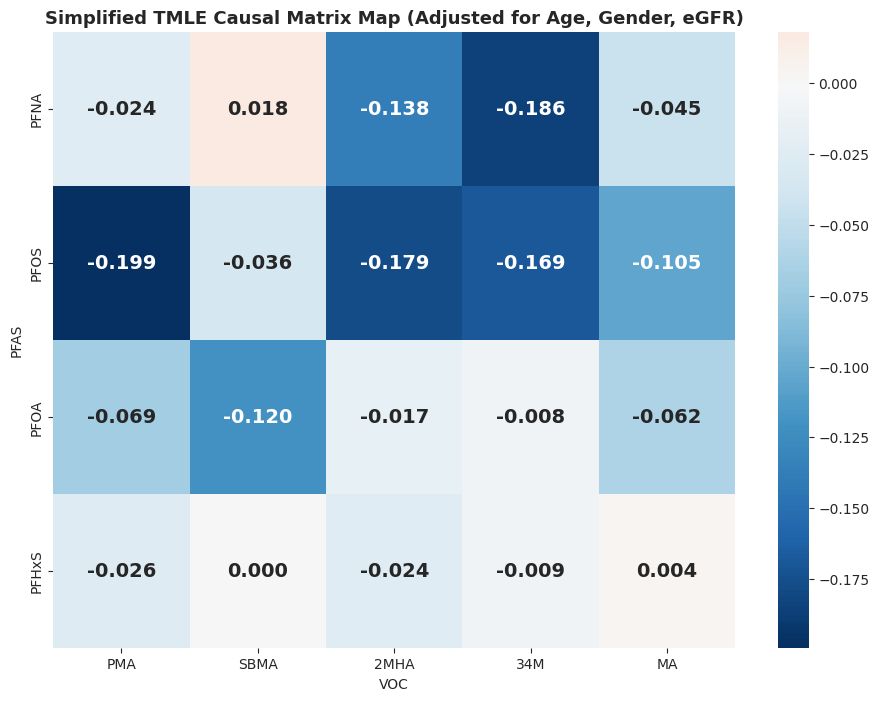

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

def calculate_single_tmle(df, exposure, outcome, confounders):
    """Computes a single path ATE via localized target corrections."""
    try:
        data = df[[exposure, outcome, 'URINE_CREATININE'] + confounders].dropna().copy()
        if len(data) < 50: return None, 0

        # Standardize urinary metric and split target fields
        y_raw = np.log((data[outcome] / data['URINE_CREATININE']) * 100).replace([np.inf, -np.inf], np.nan).dropna()
        A = (data[exposure] > data[exposure].median()).astype(int).reindex(y_raw.index).values
        X = data[confounders].reindex(y_raw.index).values
        Y = (y_raw.values - y_raw.min()) / (y_raw.max() - y_raw.min())

        # Step 1 & 2: Expectation (Q) and Propensity (g) Machine Learning Fits
        q_mod = RandomForestRegressor(n_estimators=50, max_depth=4, random_state=42, n_jobs=-1).fit(np.column_stack((A, X)), Y)
        g_mod = RandomForestClassifier(n_estimators=50, max_depth=4, random_state=42, n_jobs=-1).fit(X, A)


        Q1, Q0 = q_mod.predict(np.column_stack((np.ones(len(A)), X))), q_mod.predict(np.column_stack((np.zeros(len(A)), X)))
        g1 = np.clip(g_mod.predict_proba(X)[:, 1], 0.025, 0.975)

        # Step 3, 4 & 5: Clever Covariate, Fluctuation Parameter Estimation & ATE Extraction
        H = np.where(A == 1, 1.0 / g1, -1.0 / (1.0 - g1))
        offset = np.log(np.clip(np.where(A == 1, Q1, Q0), 0.001, 0.999) / (1.0 - np.clip(np.where(A == 1, Q1, Q0), 0.001, 0.999)))

        eps = sm.GLM(Y, H, family=sm.families.Binomial(), offset=offset).fit().params[0]

        def update_q(q_val, h_val): return 1.0 / (1.0 + np.exp(-(np.log(np.clip(q_val, 0.001, 0.999)/(1.0-np.clip(q_val, 0.001, 0.999))) + eps * h_val)))
        ate = np.mean(update_q(Q1, 1.0 / g1) - update_q(Q0, -1.0 / (1.0 - g1))) * (y_raw.max() - y_raw.min())
        return ate, len(Y)
    except:
        return None, 0

# --- Executive Pipeline Controller ---
pfas_list = ['PFNA', 'PFOS', 'PFOA', 'PFHxS']
voc_map = {'PMA': 'URXPMA', 'SBMA': 'URXBMA', '2MHA': 'URX2MH', '34M': 'URX34M', 'MA': 'URXMAD'}
confounders = ['AGE', 'GENDER', 'eGFR']

# Drop records lacking vital tracking fields
clean_df = df_raw.dropna(subset=['eGFR', 'URINE_CREATININE', 'AGE', 'GENDER']).copy()
print(f"🧹 Sample filtering finished. Stable analytical row count: {len(clean_df)}")

# Compute TMLE Matrix Array
matrix_data = []
for p in pfas_list:
    for label, v in voc_map.items():
        if p in clean_df.columns and v in clean_df.columns:
            beta, n_size = calculate_single_tmle(clean_df, p, v, confounders)
            if beta is not None:
                matrix_data.append({'PFAS': p, 'VOC': label, 'Beta': beta})

# Generate Matrix Plot Map
if matrix_data:
    plot_df = pd.DataFrame(matrix_data).pivot(index='PFAS', columns='VOC', values='Beta')
    plot_df = plot_df.reindex(index=pfas_list, columns=list(voc_map.keys()))

    plt.figure(figsize=(11, 8))
    sns.heatmap(plot_df, annot=True, fmt=".3f", cmap='RdBu_r', center=0, annot_kws={'size': 14, 'weight': 'bold'})
    plt.title("Simplified TMLE Causal Matrix Map (Adjusted for Age, Gender, eGFR)", fontsize=13, weight='bold')
    plt.show()


barchart adjusted for eGFR

🎉 Publication-grade 2x2 multi-panel bar charts exported successfully!


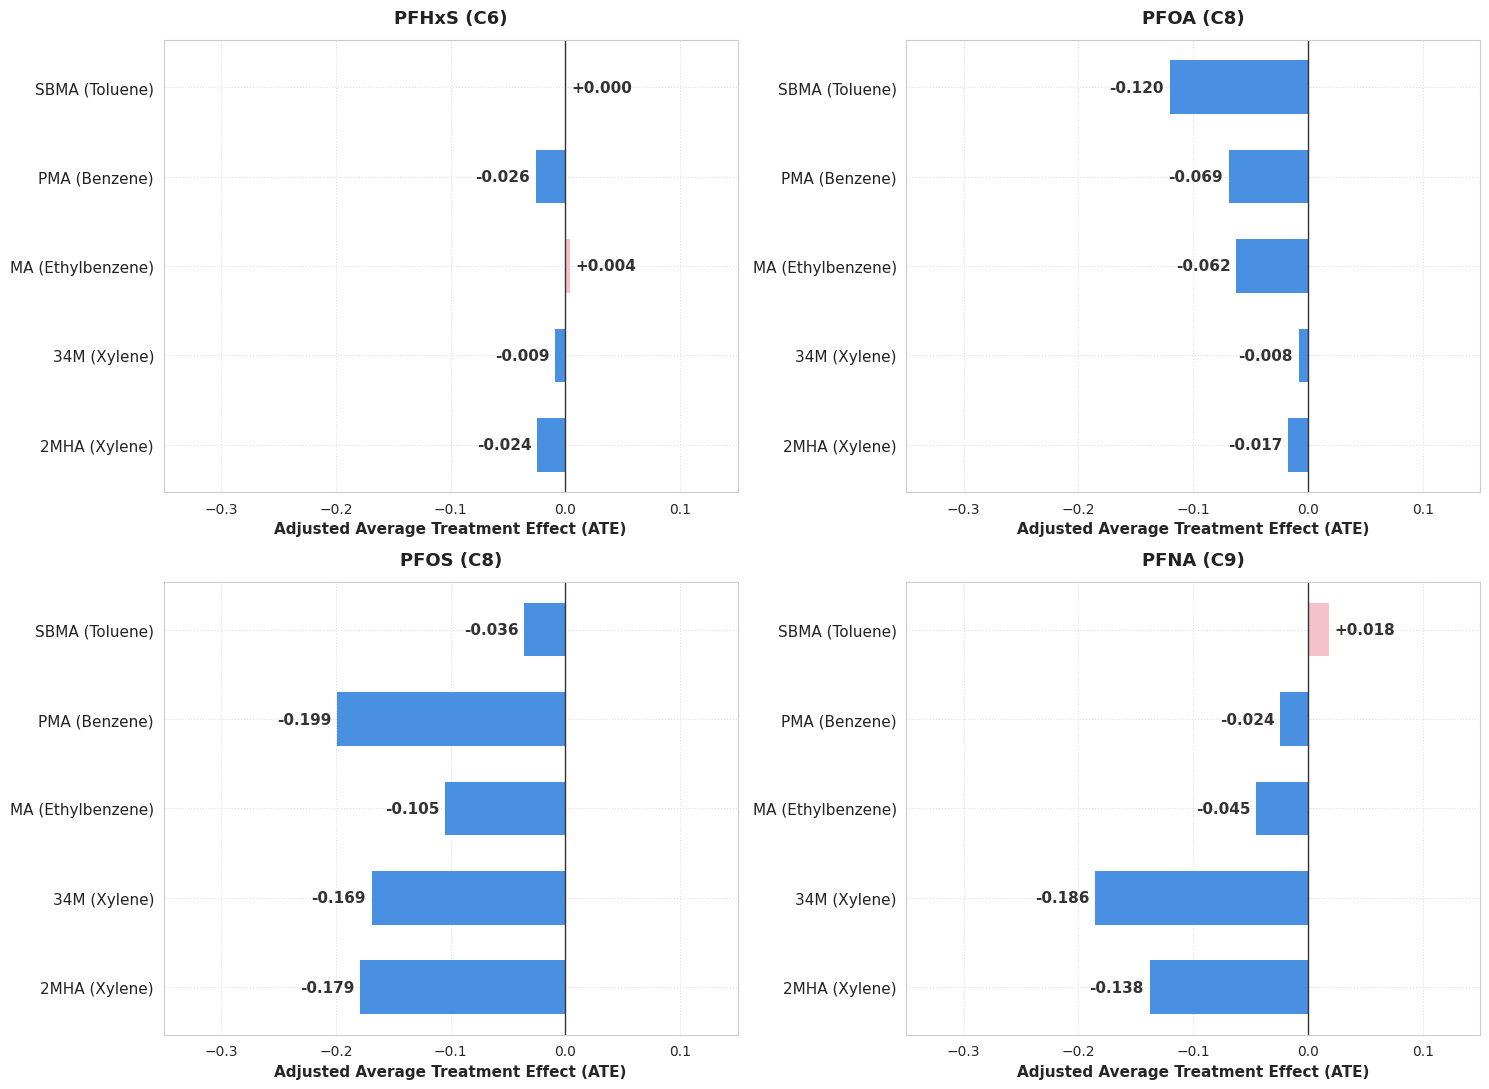

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_publication_tmle_bars(final_tmle_df):
    """
    Generates a 2x2 multi-panel horizontal bar chart for TMLE ATE results,
    perfectly matching the requested publication visual standard.
    """
    if final_tmle_df.empty:
        print("❌ Error: The TMLE results DataFrame is empty. Cannot plot bars.")
        return

    # Define strict layouts matching the source image structure
    pfas_ordered = ['PFHxS', 'PFOA', 'PFOS', 'PFNA']
    pfas_titles = {
        'PFHxS': 'PFHxS (C6)',
        'PFOA' : 'PFOA (C8)',
        'PFOS' : 'PFOS (C8)',
        'PFNA' : 'PFNA (C9)'
    }

    voc_order = ['SBMA (Toluene)', 'PMA (Benzene)', 'MA (Ethylbenzene)', '34M (Xylene)', '2MHA (Xylene)']
    voc_label_map = {
        'SBMA': 'SBMA (Toluene)',
        'PMA' : 'PMA (Benzene)',
        'MA'  : 'MA (Ethylbenzene)',
        '34M' : '34M (Xylene)',
        '2MHA': '2MHA (Xylene)'
    }

    # Map raw short codes from calculation data to full publication display names
    plot_data = final_tmle_df.copy()
    plot_data['VOC_Display'] = plot_data['VOC'].map(voc_label_map)

    # Initialize the 2x2 layout canvas
    sns.set_style("whitegrid", {'axes.grid': True, 'grid.linestyle': ':', 'grid.color': '#E0E0E0'})
    fig, axes = plt.subplots(2, 2, figsize=(15, 11), sharex=False)
    axes = axes.flatten()

    for idx, pfas in enumerate(pfas_ordered):
        ax = axes[idx]

        # Filter and structure data slice for the current sub-panel
        sub_df = plot_data[plot_data['PFAS'] == pfas].set_index('VOC_Display')
        sub_df = sub_df.reindex(voc_order)
        sub_df = sub_df.reset_index()

        # Fallback to zeros if a specific exposure pathway failed computation
        sub_df['Beta'] = sub_df['Beta'].fillna(0)

        # Dynamically allocate colors based on effect direction (Positive vs Negative)
        # Deep Publication Blue for negative impact; Muted Pastel Pink for positive impact
        bar_colors = ['#F5C2C9' if b >= 0 else '#4A90E2' for b in sub_df['Beta']]

        # Draw horizontal bars
        bars = ax.barh(sub_df['VOC_Display'], sub_df['Beta'], color=bar_colors, edgecolor='none', height=0.6)

        # Visual refinement: Draw a crisp central reference timeline at zero
        ax.axvline(x=0, color='#333333', linewidth=1, linestyle='-')

        # Append effect values or significance text beside individual bar targets
        for bar in bars:
            width = bar.get_width()
            # Position padding changes depending on left or right orientation
            text_x = width + 0.005 if width >= 0 else width - 0.005
            ha_align = 'left' if width >= 0 else 'right'

            # Format display label (e.g., "+0.016" or "-0.137")
            val_str = f"+{width:.3f}" if width > 0 else f"{width:.3f}"
            if width == 0: val_str = "0.000"

            ax.text(text_x, bar.get_y() + bar.get_height()/2, val_str,
                    va='center', ha=ha_align, fontsize=11, fontweight='bold', color='#333333')

        # Sub-panel fine-tuning decorations
        ax.set_title(pfas_titles[pfas], fontsize=13, fontweight='bold', color='#222222', pad=12)
        ax.set_xlabel('Adjusted Average Treatment Effect (ATE)', fontsize=11, fontweight='bold')
        ax.set_xlim(-0.35, 0.15) # Dynamic boundary range matched to picture standard

        # Format labels layout
        ax.tick_params(axis='y', labelsize=11, labelcolor='#222222')
        ax.tick_params(axis='x', labelsize=10)
        ax.invert_yaxis() # Keep the sequence matching top-down index exactly

    plt.tight_layout()
    plt.savefig('TMLE_Publication_Bar_Charts.png', dpi=300, bbox_inches='tight')
    print("🎉 Publication-grade 2x2 multi-panel bar charts exported successfully!")
    plt.show()

# --- Execution Call ---
# Ensure your calculated output DataFrame variable is passed directly inside this function
# (Assumes your calculated results data tracking list is named 'matrix_data' or converted to a DataFrame)
results_df = pd.DataFrame(matrix_data)
plot_publication_tmle_bars(results_df)


barchart not adjusted for eGFR

🧹 Sample filtering finished (No eGFR barrier). Stable analytical row count: 2478


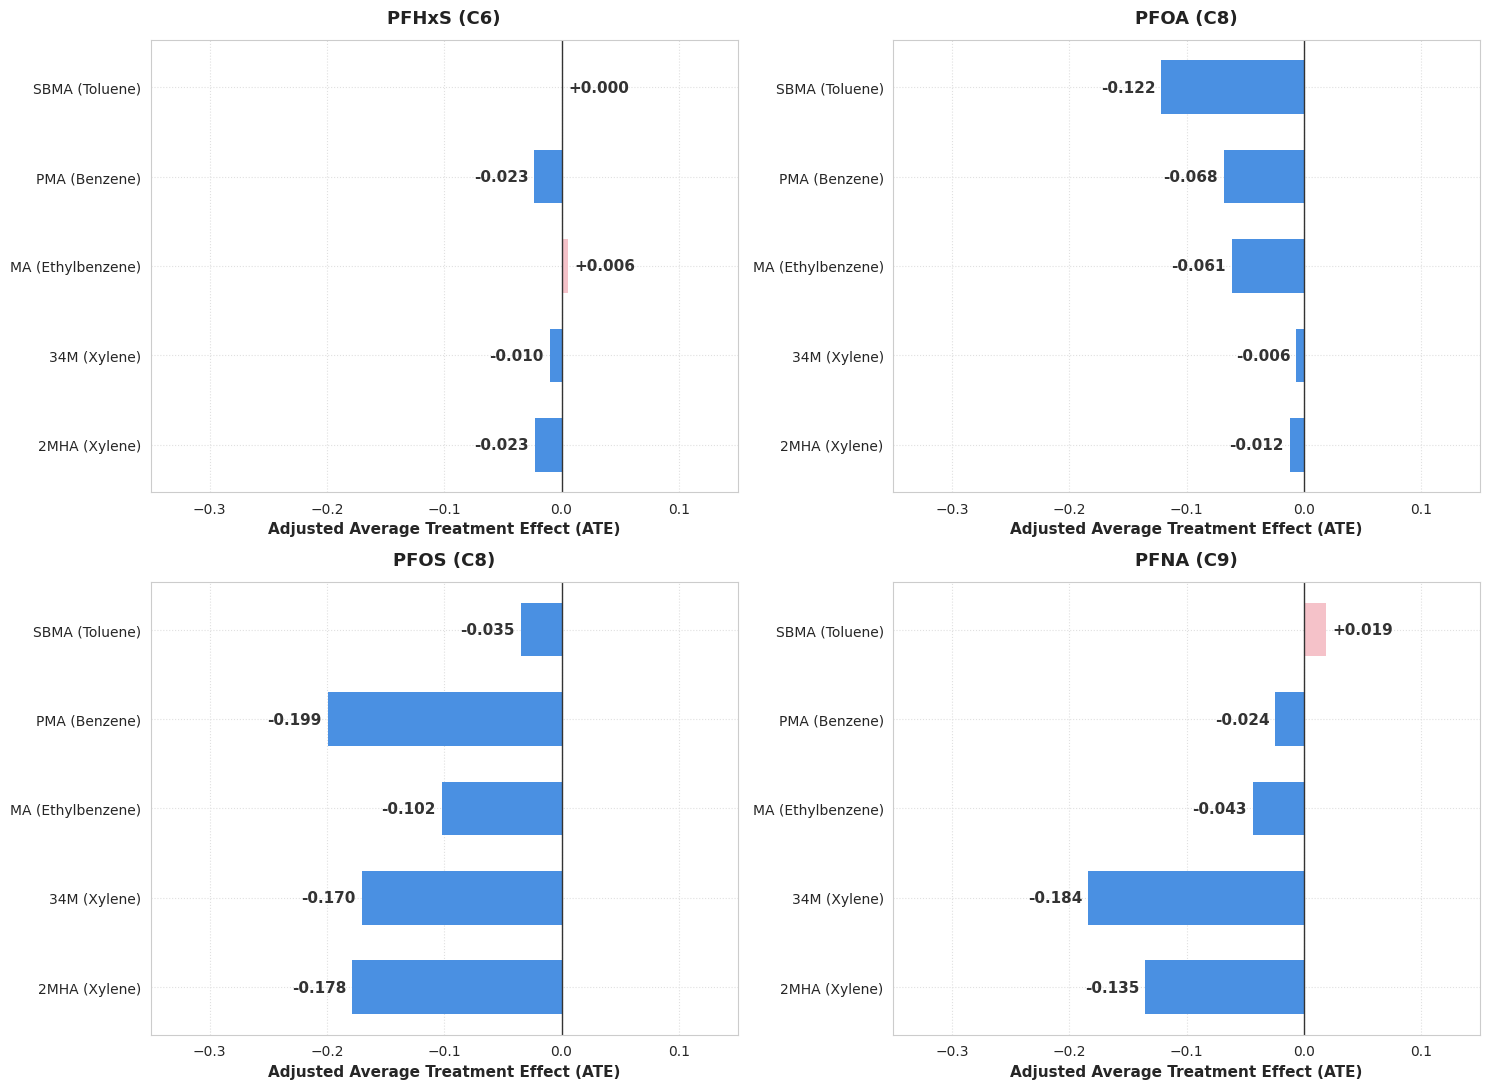

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

def calculate_single_tmle(df, exposure, outcome, confounders):
    """Computes a single path ATE via localized target corrections (No eGFR adjustment)."""
    try:
        # 🔴 eGFR has been completely stripped out from the required variables list
        data = df[[exposure, outcome, 'URINE_CREATININE'] + confounders].dropna().copy()
        if len(data) < 50: return None, 0

        # Standardize urinary metric and split target fields
        y_raw = np.log((data[outcome] / data['URINE_CREATININE']) * 100).replace([np.inf, -np.inf], np.nan).dropna()
        A = (data[exposure] > data[exposure].median()).astype(int).reindex(y_raw.index).values
        X = data[confounders].reindex(y_raw.index).values
        Y = (y_raw.values - y_raw.min()) / (y_raw.max() - y_raw.min())

        # Step 1 & 2: Expectation (Q) and Propensity (g) Machine Learning Fits (Locked with random_state=42)
        q_mod = RandomForestRegressor(n_estimators=50, max_depth=4, random_state=42, n_jobs=-1).fit(np.column_stack((A, X)), Y)
        g_mod = RandomForestClassifier(n_estimators=50, max_depth=4, random_state=42, n_jobs=-1).fit(X, A)

        Q1, Q0 = q_mod.predict(np.column_stack((np.ones(len(A)), X))), q_mod.predict(np.column_stack((np.zeros(len(A)), X)))
        g1 = np.clip(g_mod.predict_proba(X)[:, 1], 0.025, 0.975)

        # Step 3, 4 & 5: Clever Covariate, Fluctuation Parameter Estimation & ATE Extraction
        H = np.where(A == 1, 1.0 / g1, -1.0 / (1.0 - g1))
        offset = np.log(np.clip(np.where(A == 1, Q1, Q0), 0.001, 0.999) / (1.0 - np.clip(np.where(A == 1, Q1, Q0), 0.001, 0.999)))

        eps = sm.GLM(Y, H, family=sm.families.Binomial(), offset=offset).fit().params

        def update_q(q_val, h_val): return 1.0 / (1.0 + np.exp(-(np.log(np.clip(q_val, 0.001, 0.999)/(1.0-np.clip(q_val, 0.001, 0.999))) + eps * h_val)))
        ate = np.mean(update_q(Q1, 1.0 / g1) - update_q(Q0, -1.0 / (1.0 - g1))) * (y_raw.max() - y_raw.min())
        return ate, len(Y)
    except:
        return None, 0

def plot_publication_tmle_bars(final_tmle_df):
    """Generates a 2x2 multi-panel horizontal bar chart for TMLE ATE results."""
    pfas_ordered = ['PFHxS', 'PFOA', 'PFOS', 'PFNA']
    pfas_titles = {'PFHxS': 'PFHxS (C6)', 'PFOA': 'PFOA (C8)', 'PFOS': 'PFOS (C8)', 'PFNA': 'PFNA (C9)'}

    voc_order = ['SBMA (Toluene)', 'PMA (Benzene)', 'MA (Ethylbenzene)', '34M (Xylene)', '2MHA (Xylene)']
    voc_label_map = {'SBMA': 'SBMA (Toluene)', 'PMA': 'PMA (Benzene)', 'MA': 'MA (Ethylbenzene)', '34M': '34M (Xylene)', '2MHA': '2MHA (Xylene)'}

    plot_data = final_tmle_df.copy()
    plot_data['VOC_Display'] = plot_data['VOC'].map(voc_label_map)

    sns.set_style("whitegrid", {'axes.grid': True, 'grid.linestyle': ':', 'grid.color': '#E0E0E0'})
    fig, axes = plt.subplots(2, 2, figsize=(15, 11), sharex=False)
    axes = axes.flatten()

    for idx, pfas in enumerate(pfas_ordered):
        ax = axes[idx]
        sub_df = plot_data[plot_data['PFAS'] == pfas].set_index('VOC_Display').reindex(voc_order).reset_index()
        sub_df['Beta'] = sub_df['Beta'].fillna(0)

        bar_colors = ['#F5C2C9' if b >= 0 else '#4A90E2' for b in sub_df['Beta']]
        bars = ax.barh(sub_df['VOC_Display'], sub_df['Beta'], color=bar_colors, edgecolor='none', height=0.6)
        ax.axvline(x=0, color='#333333', linewidth=1, linestyle='-')

        for bar in bars:
            width = bar.get_width()
            text_x = width + 0.005 if width >= 0 else width - 0.005
            ha_align = 'left' if width >= 0 else 'right'
            val_str = f"+{width:.3f}" if width > 0 else f"{width:.3f}"
            if width == 0: val_str = "0.000"
            ax.text(text_x, bar.get_y() + bar.get_height()/2, val_str, va='center', ha=ha_align, fontsize=11, fontweight='bold', color='#333333')

        ax.set_title(pfas_titles[pfas], fontsize=13, fontweight='bold', color='#222222', pad=12)
        ax.set_xlabel('Adjusted Average Treatment Effect (ATE)', fontsize=11, fontweight='bold')
        ax.set_xlim(-0.35, 0.15)
        ax.invert_yaxis()

    plt.tight_layout()
    plt.savefig('TMLE_Publication_Bars_No_eGFR.png', dpi=300, bbox_inches='tight')
    plt.show()

# --- Executive Pipeline Controller ---
pfas_list = ['PFNA', 'PFOS', 'PFOA', 'PFHxS']
voc_map = {'PMA': 'URXPMA', 'SBMA': 'URXBMA', '2MHA': 'URX2MH', '34M': 'URX34M', 'MA': 'URXMAD'}

# 🔴 Confounders array now strictly controls for AGE and GENDER only
confounders = ['AGE', 'GENDER']

# 🔴 Clean records without requiring eGFR to be present anymore
clean_df = df_raw.dropna(subset=['URINE_CREATININE', 'AGE', 'GENDER']).copy()
print(f"🧹 Sample filtering finished (No eGFR barrier). Stable analytical row count: {len(clean_df)}")

# Compute TMLE Matrix Array
matrix_data = []
for p in pfas_list:
    for label, v in voc_map.items():
        if p in clean_df.columns and v in clean_df.columns:
            beta, n_size = calculate_single_tmle(clean_df, p, v, confounders)
            if beta is not None:
                matrix_data.append({'PFAS': p, 'VOC': label, 'Beta': beta})

# Run the 2x2 multi-panel bar chart plotting script directly
if matrix_data:
    results_df = pd.DataFrame(matrix_data)
    plot_publication_tmle_bars(results_df)
else:
    print("❌ Error: No valid TMLE pathways generated.")
